<a href="https://colab.research.google.com/github/umslengineering/EE1108/blob/main/EE1108_ex18_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Class Continued

Show Disks

In [ ]:
## ThePointClass.py

from math import sqrt, sin, cos, radians
from random import uniform as randu


class Point:
    """
    Represents a 2D point.

    Attributes:
        x (float): x-coordinate
        y (float): y-coordinate
    """

    def __init__(self, x: float, y: float) -> None:
        self.x = float(x)
        self.y = float(y)

    def __str__(self) -> str:
        """Pretty string representation."""
        return f"({self.x:6.3f}, {self.y:6.3f})"

    def Dist(self, other: "Point") -> float:
        """Return distance to another point."""
        return sqrt((self.x - other.x) ** 2 + (self.y - other.y) ** 2)

    def rotate(self, theta: float) -> "Point":
        """
        Rotate the point counterclockwise by theta degrees.
        """
        rad = radians(theta)
        c, s = cos(rad), sin(rad)
        return Point(
            self.x * c - self.y * s,
            self.x * s + self.y * c
        )

    def reflect(self) -> "Point":
        """
        Reflect the point across the line y = x.
        """
        return Point(self.y, self.x)


In [ ]:
# TheDiskClass.py
""" Contains a class that can be used for representing
disks in the plane.
"""

# from ThePointClass import *

class Disk:
    """
    Attributes:
        center: Point, the center of the disk
        radius: float, the radius of the disk

    """
    def __init__(self,P,r):
        """ Creates a Disk object with center P and radius r
        PreC: P is a Point and r is a positive float
        """
        self.center = P
        self.radius = r

    def Intersects(self,other):
        """ Returns True if self and other intersect and False otherwise
        PreC: self and other are disks
        """
        # The center-to-center distance:
        c1 = self.center
        c2 = other.center
        d = c1.Dist(c2)
        # The sum of the two radii
        radiusSum = self.radius + other.radius
        TheyIntersect = (radiusSum >= d )
        return TheyIntersect


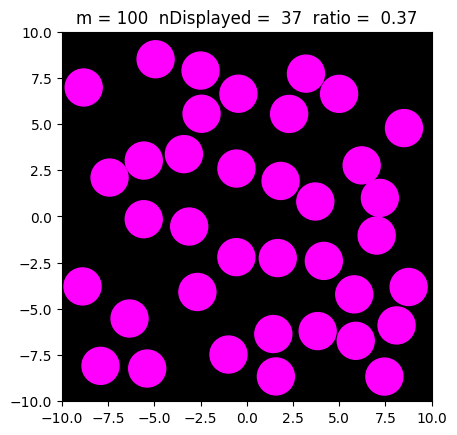

In [ ]:
# ShowDiskClass.py

import numpy as np
import matplotlib.pyplot as plt
from random import uniform as randu
# from ThePointClass import Point
# from TheDiskClass import Disk


#Purpose: Check if a new disk D0 does NOT intersect any disk in a list.
# Parameters:
# D0: Disk → the new disk to check
# disks: list[Disk] → existing disks
# Loop over every disk d in disks.
# If d.Intersects(D0) → D0 touches or overlaps with d, return False.
# If none intersect → return True.
# Intersects is a method in the Disk class that checks for overlap between circles.

def outside_all(D0: Disk, disks: list[Disk]) -> bool:
    for d in disks:
        if d.Intersects(D0):
            return False
    return True


def random_disk(n: int) -> Disk:
    return Disk(Point(randu(-n, n), randu(-n, n)), 1.0)

# Purpose: Draw a disk on a plot.
# ax → a Matplotlib axes object
# D: Disk → disk to draw
# color → color of the circle (default "magenta")
# plt.Circle(center, radius, color) creates a circle patch.
# ax.add_patch(circle) adds the circle to the axes.
# Note: D.center.x and D.center.y come from the Point class.
def show_disk(ax, D: Disk, color="magenta"):
    circle = plt.Circle(
        (D.center.x, D.center.y),
        D.radius,
        color=color
    )
    ax.add_patch(circle)


if __name__ == "__main__":
    n = 10
    # m number of disks to attempt to place.
    m = 100

    fig, ax = plt.subplots()
    ax.set_xlim(-n, n)
    ax.set_ylim(-n, n)
    ax.set_aspect(1)
    ax.set_facecolor("black")

    #disk_list → stores all disks successfully placed without overlap.
    disk_list: list[Disk] = []

    for  _ in range(m):
        # Create a random disk with coordinates in [-n+1, n-1].
        #Note: n-1 ensures the disk of radius 1 stays inside the square.
        D = random_disk(n - 1)

        if outside_all(D, disk_list): #This ensures non-overlapping disks are drawn
            show_disk(ax, D, "magenta")
            disk_list.append(D)

    n_displayed = len(disk_list)
    ratio = n_displayed / float(m)

    ax.set_title(f"m = {m:3d}  nDisplayed = {n_displayed:3d}  ratio = {ratio:5.2f}")

    plt.show()